# Quais Jogos têm Sucesso

As empresas dos dias entrentam grandes problemas e a empresa Ice não é excessão, um dos problemas que esta empresa enfrenta é a falta de informações que permitam prever o sucesso dos jogos nos proximos anos, como forma de atender o pedido dela foi iniciado este projeto que irá nos permitir tirar informações acerca do sucesso dos jogos utilizando os dados que a empresa ja possui.

## Iniciação

Como forma de iniciar a explorar os dados é interessante importar bibliotecas como o pandas, numpy e math para que se possa usar as suas funções e importar os dados do arquivo "games.csv" e trabalhar com estes dados em formato de objeto dataframes para que seja viavel a manipulação de dados em massa e analise dos mesmos dados.

**Carregando Bibliotecas Necessarias**

Na celula abaixo é feita a importação de bibliotecas para a manipulação de dataframes como o **pandas**, para a execução de calculos como o **numpy** e o **math** e por fim bibliotecas **pyplot** e **stats** para criação de graficos e execução de testes de hipoteses respetivamente.

In [1]:
#carregando as bibliotecas necessarias

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns

## Carregando os dados

Os dados que nos foram fornecidos para usar como base da analise estão armazenados no arquivo games.csv e nesta secção iremos importar para um objeto dataframes que é viável para calculos e analises estatisticas.

**Importando os dados para dataframes**

In [2]:
#Criando dataframe apartir do arquivo games.csv

df = pd.read_csv('/datasets/games.csv')

## Exploração dos dados

A empresa Ice disponibilizou um conjunto de dados que é composto pelas seguintes componentes no dataframe df de**games:**

- **Name** (nome)
- **Platform** (plataforma)
- **Year_of_Release** (Ano de lançamento)
- **Genre**(gênero)
- **NA_sales** (vendas norte-americanas em milhões de USD)
- **EU_sales** (vendas na Europa em milhões de USD)
- **JP_sales** (vendas no Japão em milhões de USD)
- **Other_sales** (vendas em outros países em milhões de USD)
- **Critic_Score** - (Pontuação crítica) (máximo de 100)
- **User_Score** - (Pontuação do usuário) (máximo de 10)
- **Classificação** (ESRB)

**Imprimindo as informações sobre o dataframe**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


**A revelar informações sobre as variaveis numericas**

In [4]:
df.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


**Imprimindo as dez(10) primeiras linhas dataframe**

In [5]:
print(df.head(10))

                        Name Platform  Year_of_Release         Genre  \
0                 Wii Sports      Wii           2006.0        Sports   
1          Super Mario Bros.      NES           1985.0      Platform   
2             Mario Kart Wii      Wii           2008.0        Racing   
3          Wii Sports Resort      Wii           2009.0        Sports   
4   Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing   
5                     Tetris       GB           1989.0        Puzzle   
6      New Super Mario Bros.       DS           2006.0      Platform   
7                   Wii Play      Wii           2006.0          Misc   
8  New Super Mario Bros. Wii      Wii           2009.0      Platform   
9                  Duck Hunt      NES           1984.0       Shooter   

   NA_sales  EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     41.36     28.96      3.77         8.45          76.0          8      E  
1     29.08      3.58      6.81         0.77     

**Conclusões e Interpretações dos dados**

Pela rápida investigação feita nos dados enviados pela empresa foi possivel encontrar algumas irregularidades como valores ausentes nas colunas **name**, **year_of_release**, **genre**, **critic_score**, **user_score** e **rating**. Há também colunas que não estão a ser representadas por tipos de dados mais apropriados para os dados da coluna, então converter estes tipos de dados para que seja facil processar e analisar os dados destas colunas seria o mais certo.

## A renomear as colunas

Nesta secção eu gostaria de alterar o nome das colunas e torna-las escritas apenas com letras minusculas.

In [6]:
df = df.rename(
    columns = { 
    'Name': 'name',
    'Platform': 'platform',
    'Year_of_Release':'year',
    'Genre': 'genre',
    'NA_sales':'na_sales',
    'EU_sales': 'eu_sales', 
    'JP_sales': 'jp_sales',
    'Other_sales':'other_sales',
    'Critic_Score': 'critic_score',
    'User_Score': 'user_score',
    'Rating': 'rating'
})

## Convertendo para tipos de dados viáveis

__Convertendo a coluna user score para float__

In [7]:
# df.astype({'user_score': 'float'})['user_score']
df.user_score = pd.to_numeric(df['user_score'], errors="coerce")
# df[df.user_score == 'tbd']

## Resolvendo os valores ausentes

As linhas de indice 659 e 14244 aparentam ser a mesma linha duplicada e como há apenas um valor na coluna JP_sales de 14244 que não esta em 659 irei copiar este valor para 659 e eliminar a linha 14244 para eliminar estes dados duplicados, mas estes duplicados são implicitos então o metodo duplicated não consegue os detetar mas é possivel ver assim que vejo os valores ausentes na coluna Name, isso provavelmente explica a razão destas duas linhas não terem valores na coluna Names.

**Identificando as linhas duplicadas**

In [8]:
df[df['name'].isna() == True]

,name,platform,year,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


__Copiando os valores de uma linha para a outra e eliminando a coluna extra__

In [9]:
df.at[659, 'jp_sales'] = float(df.xs(14244)['jp_sales'])
df = df.drop([14244]).reset_index(drop=True)


__Atribuindo o valor 'unknown' para a linha 659__

In [10]:
df.at[659, 'name'] = 'unknown'

__Resolvendo os valores ausentes em Genre__

In [11]:
df[df['genre'].isna() == True]

,name,platform,year,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,unknown,GEN,1993.0,NaN,1.78,0.53,0.03,0.08,NaN,NaN,NaN


In [12]:
df.at[659, 'genre'] = df.query('year == 1993 and platform == "GEN"')['genre'].mode()[0]

__Resolvendo os valores ausentes em year of release__

In [1]:

genres = ['Action', 'Sports', 'Misc', 'Role-Playing', 'Shooter', 'Adventure', 'Racing', 'Platform', 'Simulation',
          'Fighting',  'Strategy', 'Puzzle']
genres_medians = {}
for genre in genres:
    genres_medians[genre] = df[df['genre'] == genre]['year'].mode()[0]

    
def calc_mode_year_release(row):
    year_release = row['year']
    genre = row['genre']
    if math.isnan(year_release) == True:
        return int(genres_medians[genre])
    else:
        return int(year_release)
        
    
    
df['year'] = df.apply(calc_mode_year_release, axis=1)
# df['Year_of_Release'].value_counts()

NameError: name 'df' is not defined

__Criando funções para preencher os valores de userscore, criticscore e ratings__

In [14]:
def fill_user_score(row):
    score = row['user_score']
    genre = row['genre']
    if math.isnan(score) == True:
        return df.query(f'genre == "{genre}"')['user_score'].median()
    else:
        return score
    
def fill_critic_score(row):
    score = row['critic_score']
    genre = row['genre']
    if math.isnan(score) == True:
        return df.query(f'genre == "{genre}"')['critic_score'].median()
    else:
        return score 

def fill_rating_mode(row):
    rating = row['rating']
    platform = row['platform']
    genre = row['genre']
    year = row['year']
    if not isinstance(rating, str):
        return df.query(f'genre == "{genre}"')['rating'].mode()[0]

    else:
        return rating


**Preenchendo os valores ausentes em user_score**

In [15]:
df['user_score'] = df.apply(fill_user_score, axis=1)


__Preenchendo os valores ausentes em critic score__

In [16]:
df['critic_score'] = df.apply(fill_critic_score, axis=1)

__Preenchendo os valores ausentes em ratings__

In [17]:
df['rating'] = df.apply(fill_rating_mode, axis=1)


## Calculando o total de vendas

__Criando função para calcular a soma__

In [18]:
def calc_total_vendas(row):
    na = row['na_sales']
    eu = row['eu_sales']
    jp = row['jp_sales']
    other = row['other_sales']
    return (na + eu + jp + other)

__Criando a coluna total de vendas__

In [19]:
df['total_sales'] = df.apply(calc_total_vendas, axis=1)

## Analise de Dados

### Analisando jogos lançados em epocas diferentes

 Os jogos lançados em epocas diferentes normalmente têm valores numericos em seu nome então nesta celula abaixo eu executei uma filtragem para jogos que têm numeros em seu nome. O histograma apresentado abaixo ilustra como a tendencia de lançar jogos em epocas diferentes ao longo dos anos tem aumentado até 2009 e depois começou a diminuir após 2009.

<Axes: >

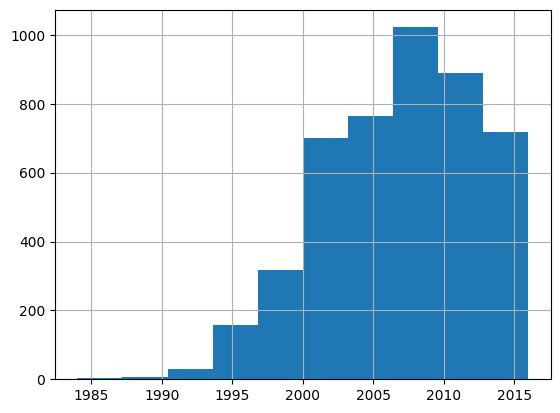

In [20]:
df[ (df['name'].str.find('1') != -1) |
   (df['name'].str.find('2') != -1 ) |
   (df['name'].str.find('3') != -1 ) |
   (df['name'].str.find('4') != -1 ) |
   (df['name'].str.find('5') != -1 ) |
   (df['name'].str.find('6') != -1 ) |
   (df['name'].str.find('7') != -1 ) |
   (df['name'].str.find('8') != -1 ) |
   (df['name'].str.find('9') != -1 ) |
   (df['name'].str.find('0') != -1 )
  ]['year'].hist()

### Vendas segmentadas por plataforma

O grafico abaixo apresenta uma visualização das plataformas que têm obtido mais vendas como PS, PS2, PS3, PSP, Wii, xbox e DS.

<Axes: xlabel='platform'>

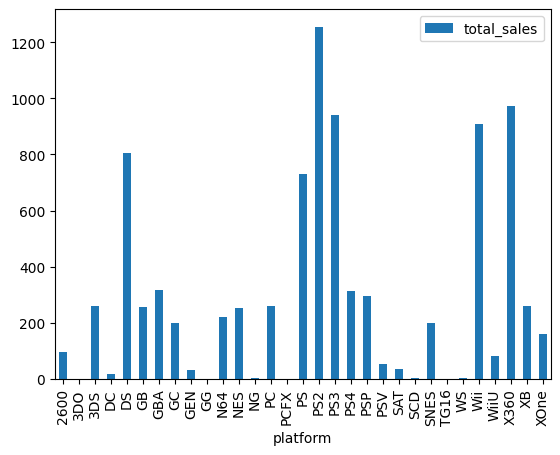

In [21]:
df.pivot_table(index='platform', values='total_sales', aggfunc='sum').plot(kind='bar')
# df['platform'].value_counts().plot(kind='bar')

### Vendas de jogos ao longo dos anos

 A celula abaixo oferece um grafico das vendas ao longo dos anos.

<Axes: xlabel='year'>

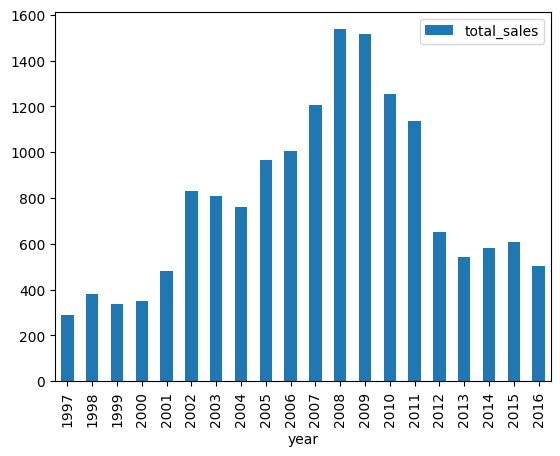

In [22]:
df.pivot_table(index=['year'], values='total_sales', aggfunc='count').query('total_sales > 270').plot(kind='bar')

### Plataformas que ja não são populares

__Plataformas que costumavam ser populares:__

O grafico abaixo apresenta o grafico das plataformas populares ao longo dos anos e permite-nos ver que as plataformas populares entre o ano 2006 e 2012 e o segundo grafico ilustra as plataformas que ja não são populares apos 2012 e as que se tornaram populres após 2012 


Axes(0.125,0.11;0.775x0.77)


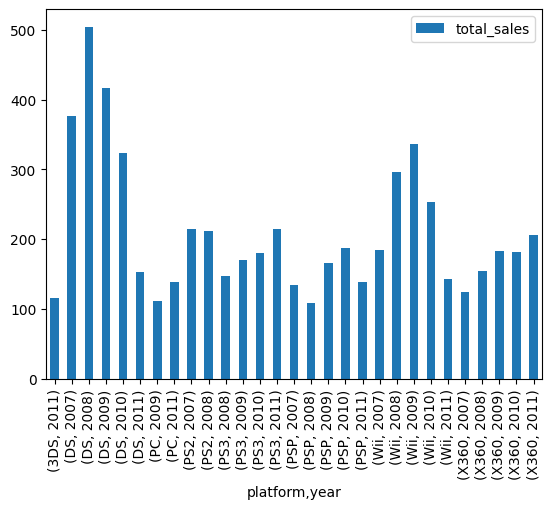

Axes(0.125,0.11;0.775x0.77)


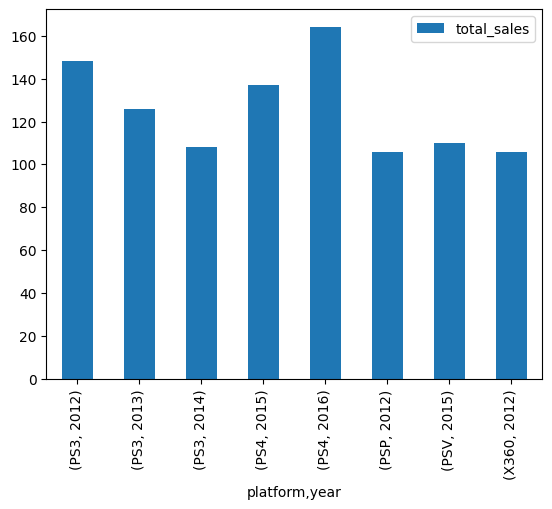

In [23]:
print(df.pivot_table(index=['platform', 'year'], values='total_sales', aggfunc='count')\
      .query('total_sales > 100 and year > 2006 and year < 2012').plot(kind='bar'))
plt.show()
print(df.pivot_table(index=['platform', 'year'], values='total_sales', aggfunc='count')\
      .query('total_sales > 100 and year >= 2012').plot(kind='bar'))

__Tempo que leva para as novas plataformas aparecerem e as antigas desaparecerem:__

Este grafico nos dá informação clara que as plataformas ficam populares por 4 a 6 anos e depois desaparecem e surgem outras plataformas com as mais populares.

Axes(0.125,0.11;0.775x0.77)


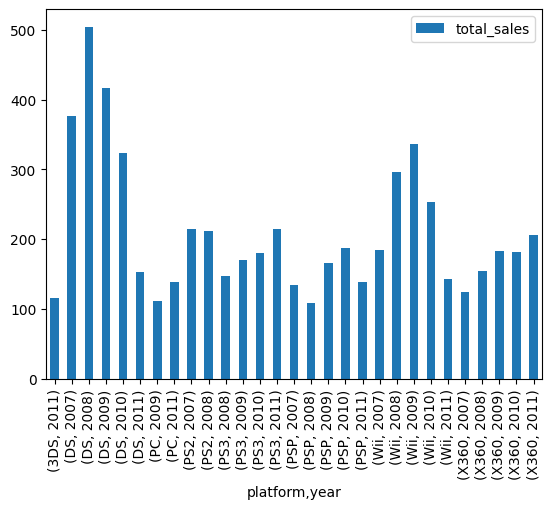

In [24]:
print(df.pivot_table(index=['platform', 'year'], values='total_sales', aggfunc='count')\
      .query('total_sales > 100 and year > 2006 and year < 2012').plot(kind='bar'))
plt.show()

__Modelo para 2017__

Analisando a tendencia das plataformas é possivel ver que as plataformas levam 4 a 5 anos então para criar um modelo para 2017  foi analisada as tendencias apos o ano 2013, esta que apresenta as plataformas em ascenção como PS4, PSV, PS3, XOne e 3DS.


Axes(0.125,0.11;0.775x0.77)


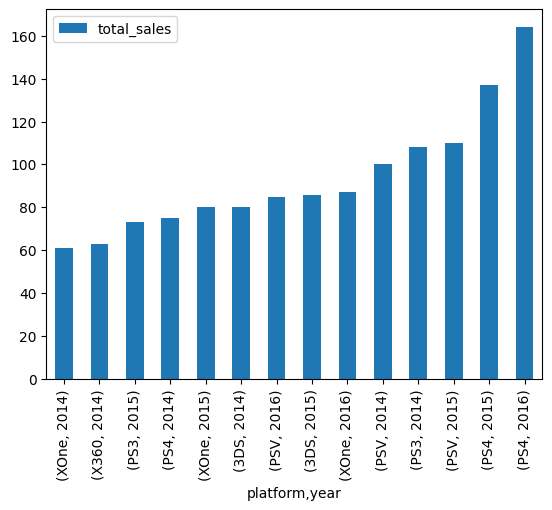

In [25]:
print(df.pivot_table(index=['platform', 'year'], values='total_sales', aggfunc='count')\
      .sort_values(['total_sales'], ascending=[1]).query('total_sales > 60 and year > 2013').plot(kind='bar'))
plt.show()

__Filtrar dados anteriores a 2013__

Este trecho de codigo vai criar um novo dataframe contendo apenas dados de jogos lançados apos ou no ano 2013.

In [27]:
df_filtered = df.query('year >= 2013')


__Plataformas liderando as vendas__

Este grafico nesta secção nos apresenta as plataformas que estão liderando as vendas do periodo de 2013 a 2016.

Axes(0.125,0.11;0.775x0.77)


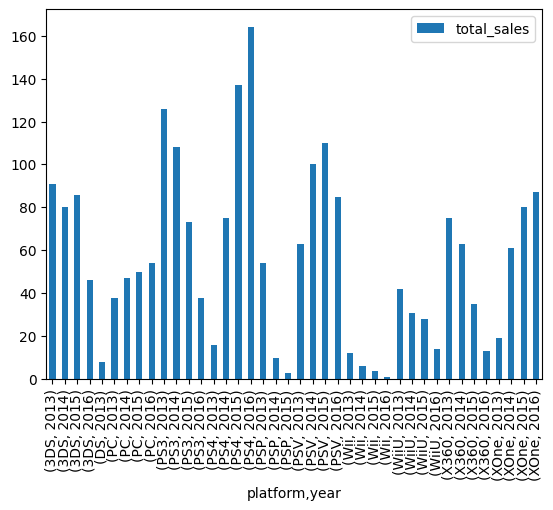

In [28]:
print(df_filtered.pivot_table(index=['platform', 'year'], values='total_sales', aggfunc='count')\
      .plot(kind='bar'))
plt.show()

__Vendas globais de jogos por Plataforma__

Os diagramas abaixo ilustram os dados e a distribuição das vendas por plataforma e até mesmo as vendas anormais em cada plataforma.

Vendas na plataforma Wii


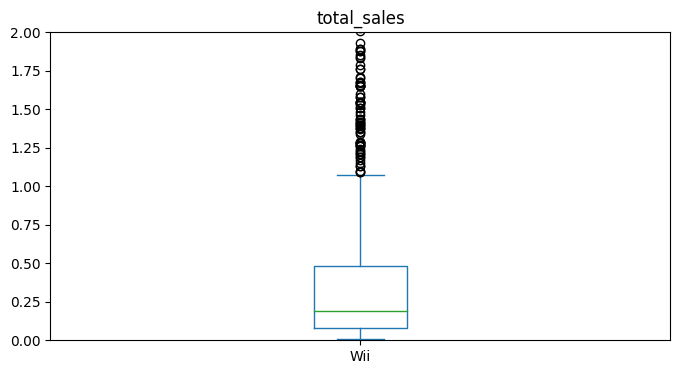

Vendas na plataforma NES


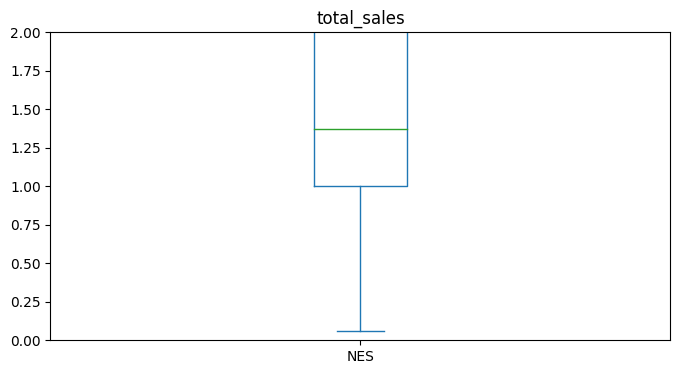

Vendas na plataforma GB


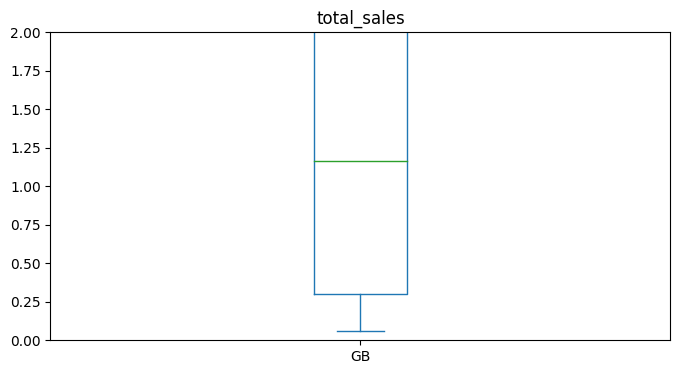

Vendas na plataforma DS


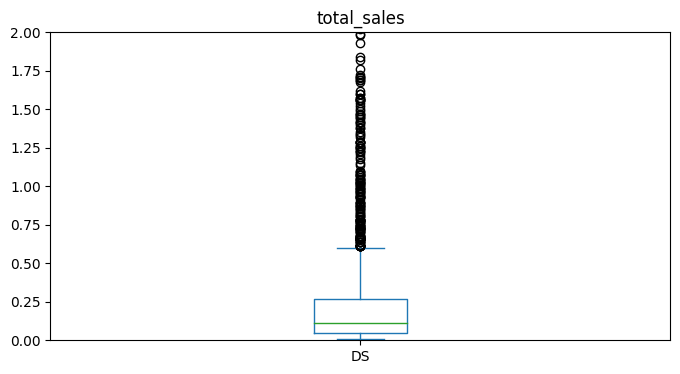

Vendas na plataforma X360


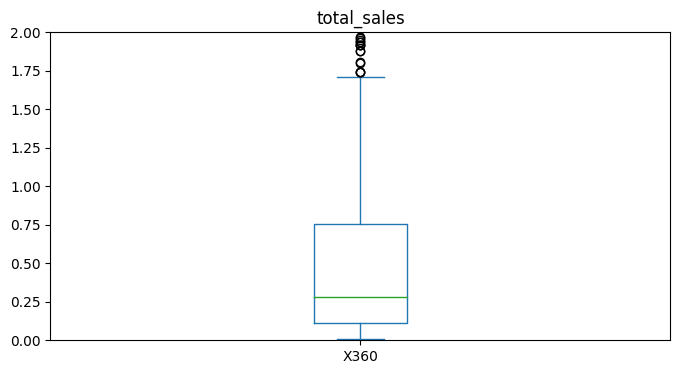

Vendas na plataforma PS3


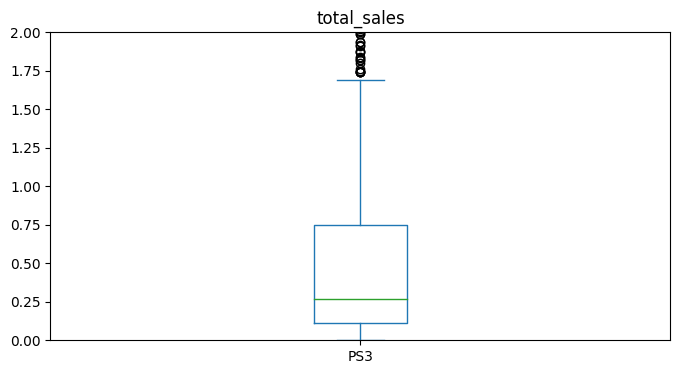

Vendas na plataforma PS2


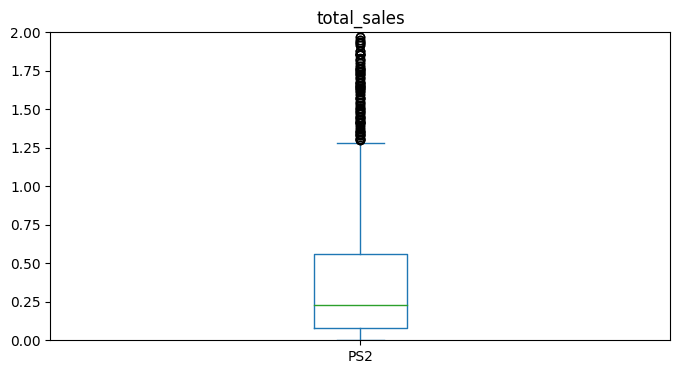

Vendas na plataforma SNES


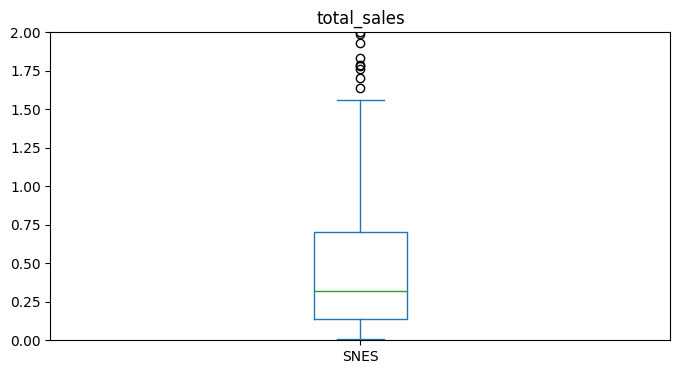

Vendas na plataforma GBA


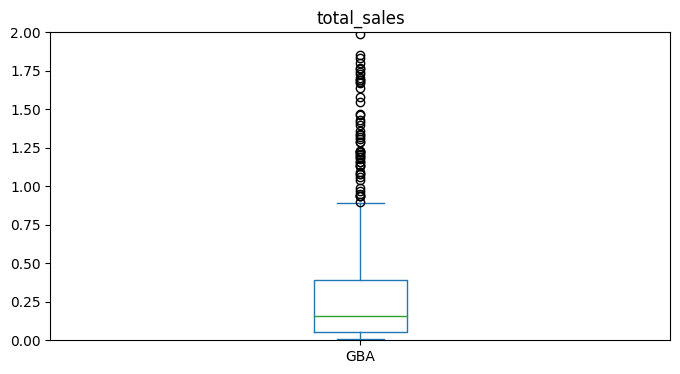

Vendas na plataforma PS4


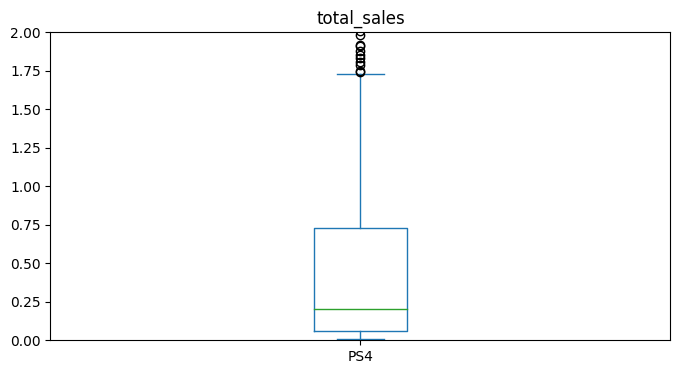

Vendas na plataforma 3DS


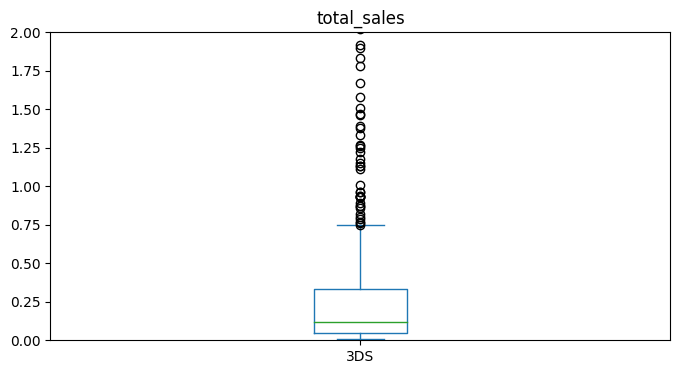

Vendas na plataforma N64


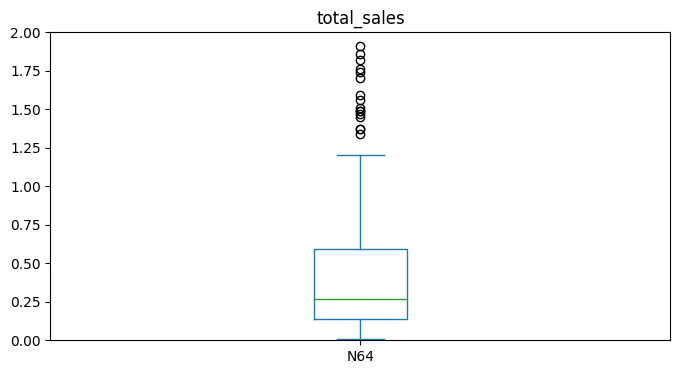

Vendas na plataforma PS


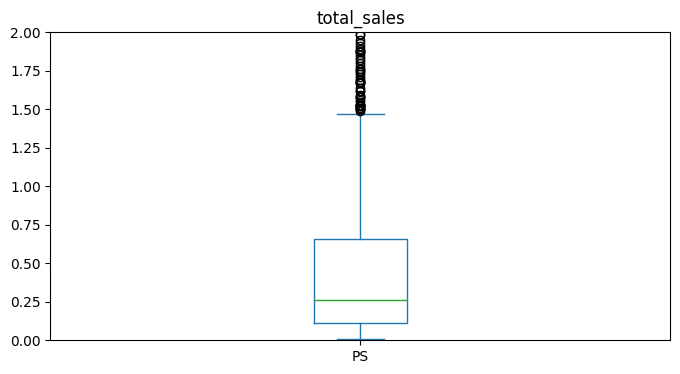

Vendas na plataforma XB


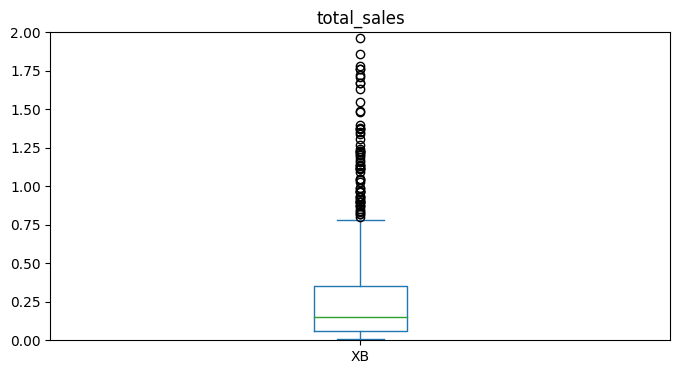

Vendas na plataforma PC


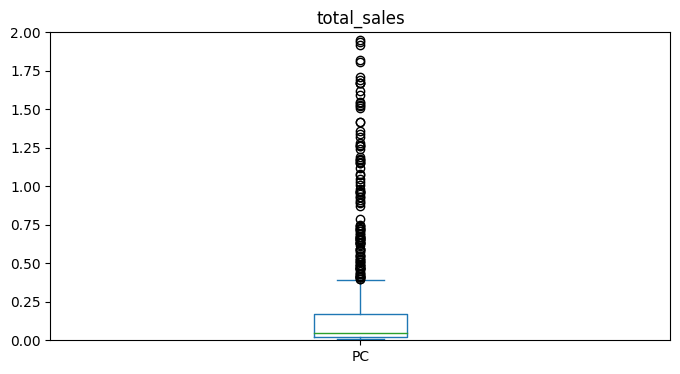

Vendas na plataforma 2600


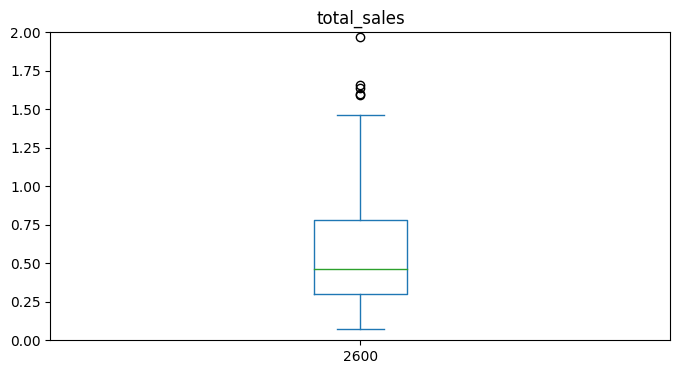

Vendas na plataforma PSP


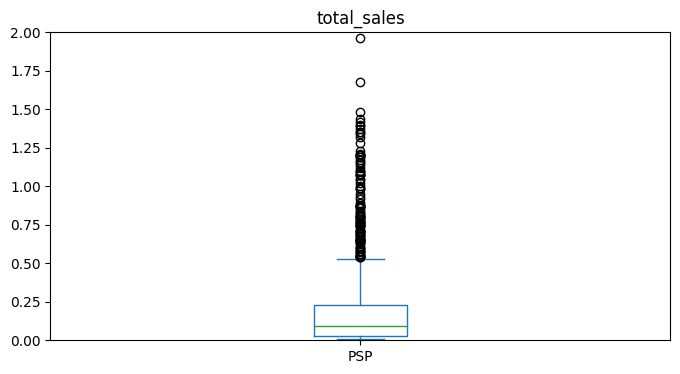

Vendas na plataforma XOne


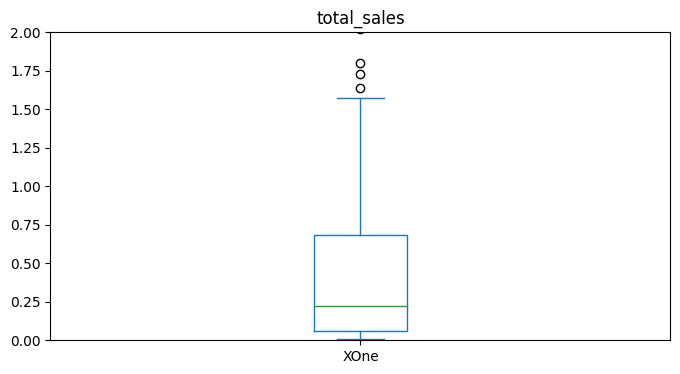

Vendas na plataforma WiiU


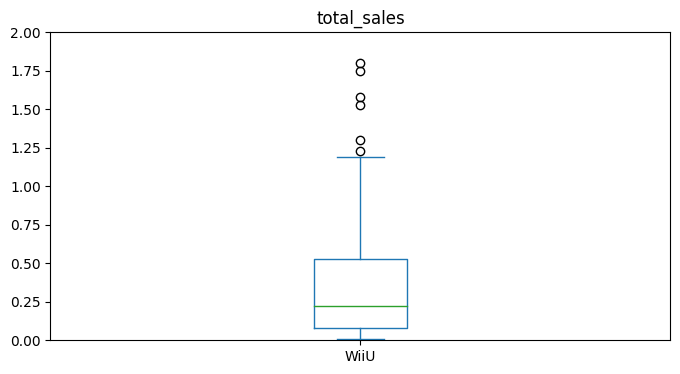

Vendas na plataforma GC


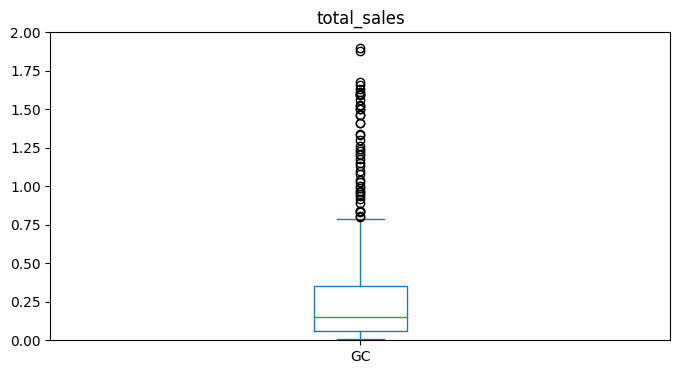

Vendas na plataforma GEN


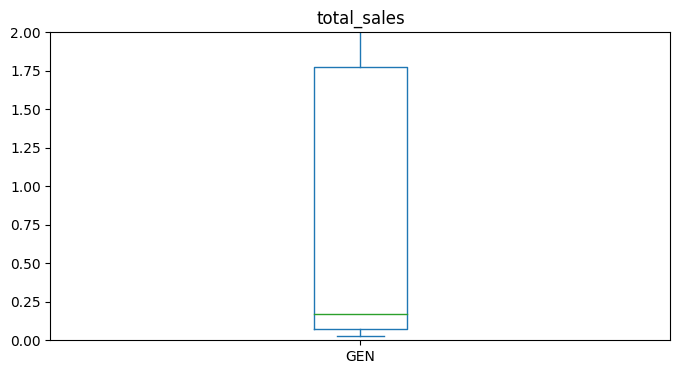

Vendas na plataforma DC


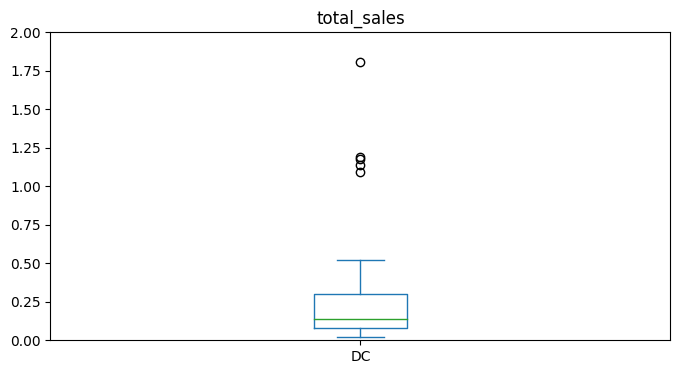

Vendas na plataforma PSV


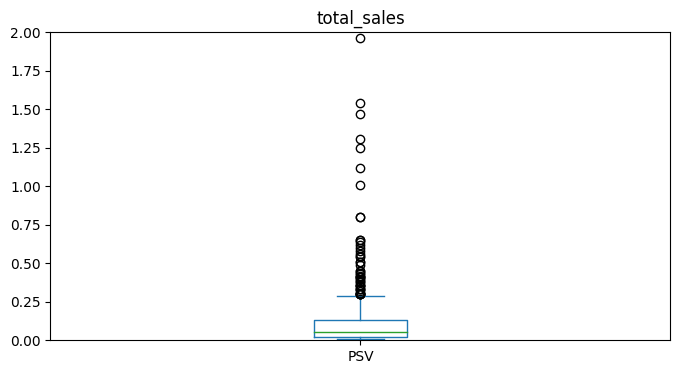

Vendas na plataforma SAT


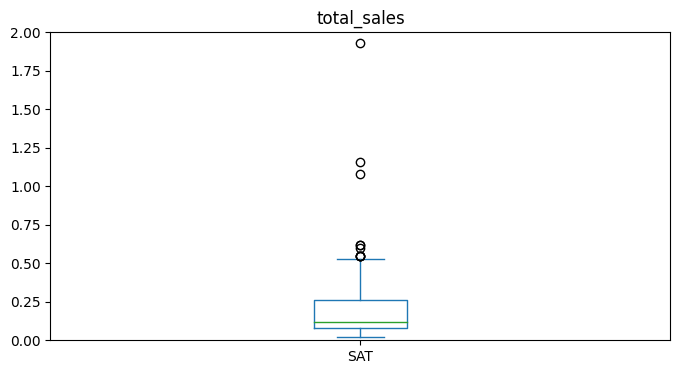

Vendas na plataforma SCD


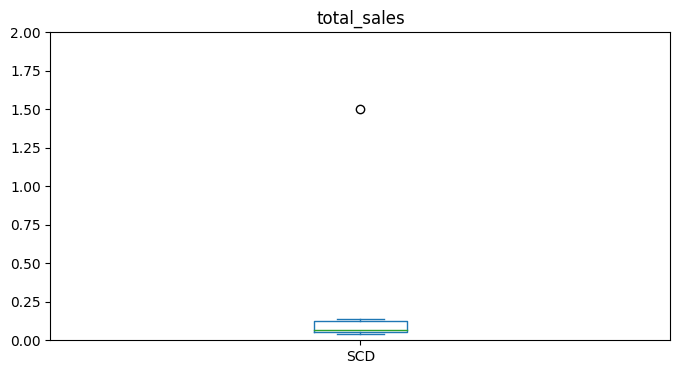

Vendas na plataforma WS


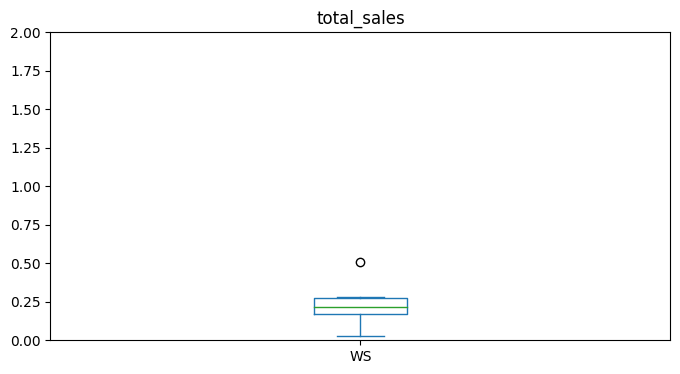

Vendas na plataforma NG


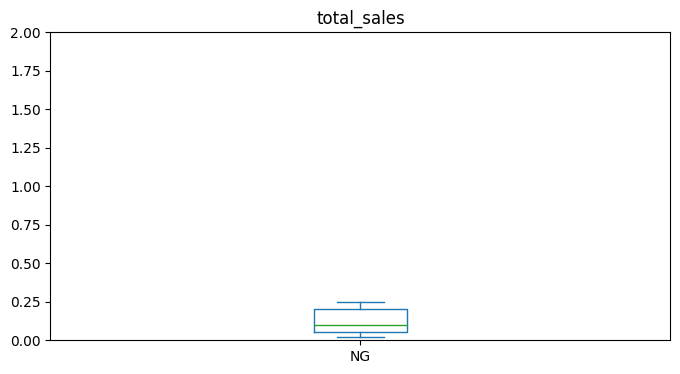

Vendas na plataforma TG16


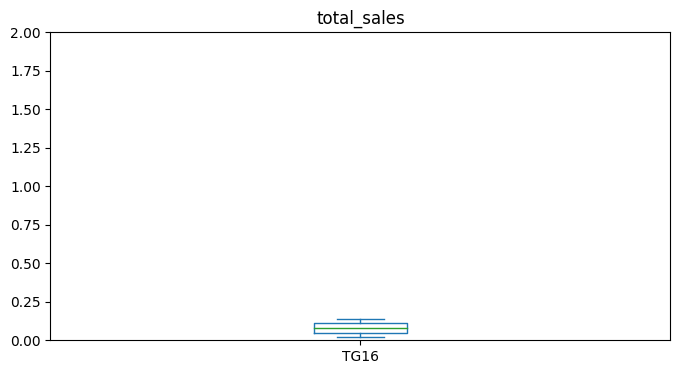

Vendas na plataforma 3DO


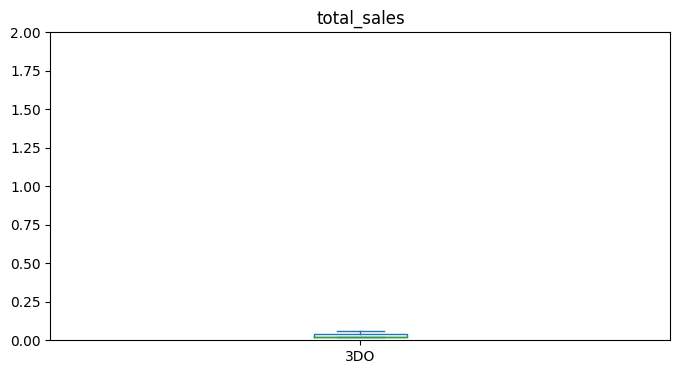

Vendas na plataforma GG


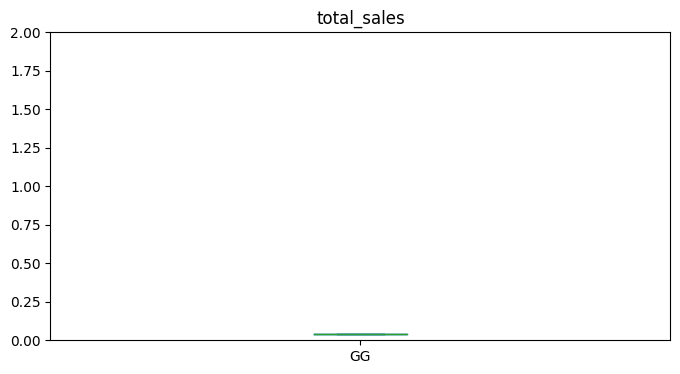

Vendas na plataforma PCFX


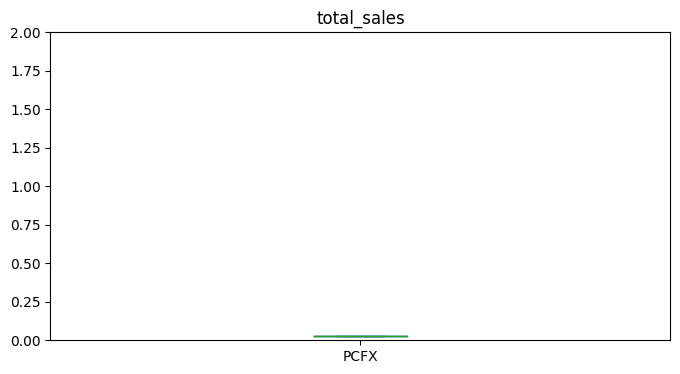

In [29]:
platforms = df.platform.unique()

for platform in platforms:
    print(f'Vendas na plataforma {platform}')
    
    df[df['platform'] == platform].plot.box(column='total_sales', by='platform', figsize=(8,4))
    plt.ylim(0,2)
    plt.show()



__Breves Conclusões__

As analises até este periodo nos permitiram ver as plataformas que têm sido lucrativa ao longo dos anos e também no da uma perspetiva de como as vendas têm sido do ano 2013 para frente e quais plataformas estão com a tendencia de crescerem em 2017 no que tange a lucrabilidade.

__Como as avaliações dos profissionais afetam as vendas da PS2__

As avaliações dos profissionais têm afetado bastante as vendas da PS2 onde jogos com classificações tiradas entre 0 a 50 têm se saido muito bem nas vendas e os jogos com classificação superior a 50 têm se saido muito mau. 

In [ ]:
df[df['platform'] == 'PS2'].pivot_table(index='critic_score', values='total_sales', aggfunc='count').hist()
# df.platform.unique()

__Como as avaliações dos usuarios afetam as vendas da PS2__

Os jogos com as classificações dos usuarios que têm ficado entre 0 e 75 têm se saido muito bem e os jogos com classificações maiores do que 75 não têm sido muito boas.

In [ ]:
df[df['platform'] == 'PS2'].pivot_table(index='user_score', values='total_sales', aggfunc='count').hist()
# df.platform.unique()

__Relação entre revisões de usuarios e vendas__

Este grafico de dispersão apresentado abaixo ilustra a apresentação dos dados das vendas organizadas por classificação de usuario e é possivel ver que as classificações acima de 2 têm vendido bem até as classificações 9 e depois vai diminuindo.

In [ ]:
df.plot.scatter(x='user_score', y='total_sales'  )

__Relação entre revisões de profissionais e vendas__

As revisões dos criticos profissionais também têm afetado positivamente as vendas dos jogos, quanto maior a classificação maiores as vendas

In [ ]:
df.plot.scatter(x='critic_score', y='total_sales'  )

__Correlação entre revisões dos usuarios e as vendas__

Aqui nesta celula é apresentada a correlação entre as revisões dos usuarios e as vendas dos jogos e é identificado que há uma correlação positiva mas muito fraca quase nula.

In [ ]:
print(df['user_score'].corr(df['total_sales']))

__Correlação entre revisões dos profissionais e as vendas__

As revisões dos profissionais têm uma correlação positiva maior com as vendas mas também muito fraca para poder se dizer que realmente existe uma relação entre as revisões dos profissionasi e as vendas dos jogos.

In [ ]:
print(df['critic_score'].corr(df['total_sales']))

__Breves Conclusões__

Até esta etapa foi possivel entender que as criticas são provaveis fatores para um bom numero de vendas pois quanto mais alta a classificação maior o numero de vendas. As vendas dos jogos para a plataforma "PS2" têm sido muito boas para classificações de usuario entre 0 e 75.

__Comparação das vendas dos mesmos jogos em outras plataformas__

Os graficos abaixo nos apresentam a informação que para estes referidos jogos as vendas têm sido muito boas nas plataformas ps2, ps3 e xbox.

In [ ]:
games = {'007: Quantum of Solace', 'pro evolution soccer 2011','2010 FIFA World Cup South Africa', "Adventure Time: Explore the Dungeon Because I Don't Know!",
        "Assassin's Creed IV: Black Flag"}

for game in games:
    df[df['name'] == game].pivot_table(index='platform', values='total_sales', aggfunc='sum').plot(kind='bar')

# df.pivot_table(index='name', values='platform', aggfunc='count').query('platform > 4')['platform']

__Visualização de jogos por gênero__

O grafico de barras abaixo ilustra que os jogos de genero "Action", "Sports" e "Misc" são os generos mais populares.

In [ ]:
df.pivot_table(index='genre', values='name', aggfunc='count').plot(kind='bar')

__Os generos mais Lucrativos__

Os generos de jogos mais lucrativos são estes com maiores numeros no grafico abaixo, que são:Action, Sports e Shooter.

In [ ]:
df.pivot_table(index='genre', values='total_sales', aggfunc='sum').plot(kind='bar')

__Observações sobre generos com vendas altas e baixas__

Os generos com vendas altas são:Action, Sports, Shooter, RPG, Platform, Racing e Misc. Os generos com vendas baixas são: Fighting, Simulation, Adventure, Puzzle e Strategy.

In [ ]:
print('Generos com vendas altas')
df.pivot_table(index='genre', values='total_sales', aggfunc='sum').query('total_sales > 500').plot(kind='bar')
plt.show()
print()

print('Generos com vendas baixas')
df.pivot_table(index='genre', values='total_sales', aggfunc='sum').query('total_sales < 500').plot(kind='bar')
plt.show()

## Perfil de usuarios na America do Norte

**Top 5 das plataformas mais populares**

In [ ]:
df.pivot_table(index='platform', values='na_sales', aggfunc='sum').sort_values(['na_sales'], ascending=[0]).head(5).plot(kind="bar")

**Top 5 dos Generos de jogos**

In [ ]:
df.pivot_table(index='genre', values='na_sales', aggfunc='sum').sort_values(['na_sales'], ascending=[0]).head(5).plot(kind="bar")

__Impacto das avaliações ESRB nas vendas da região__

In [ ]:
df.pivot_table(index='rating', values='na_sales', aggfunc='sum').sort_values(['na_sales'], ascending=[0]).head(5).plot(kind="bar")

## Perfil de usuarios na Europa

**Top 5 das plataformas mais populares**

In [ ]:
df.pivot_table(index='platform', values='eu_sales', aggfunc='sum').sort_values(['eu_sales'], ascending=[0]).head(5).plot(kind="bar")

__Top 5 dos Generos de jogos__

In [ ]:
df.pivot_table(index='genre', values='eu_sales', aggfunc='sum').sort_values(['eu_sales'], ascending=[0]).head(5).plot(kind="bar")

__Impacto das avaliações ESRB nas vendas da região__

In [ ]:
df.pivot_table(index='rating', values='eu_sales', aggfunc='sum').sort_values(['eu_sales'], ascending=[0]).head(5).plot(kind="bar")

## Perfil de usuarios no Japão

**Top 5 das plataformas mais populares**

In [ ]:
df.pivot_table(index='platform', values='jp_sales', aggfunc='sum').sort_values(['jp_sales'], ascending=[0]).head(5).plot(kind="bar")

__Top 5 dos Generos de jogos__

In [ ]:
df.pivot_table(index='genre', values='jp_sales', aggfunc='sum').sort_values(['jp_sales'], ascending=[0]).head(5).plot(kind="bar")

__Impacto das avaliações ESRB nas vendas da região__

In [ ]:
df.pivot_table(index='rating', values='jp_sales', aggfunc='sum').sort_values(['jp_sales'], ascending=[0]).head(5).plot(kind="bar")

__Breves Conclusões__

Estas analises nesta secção foi possivel compilar informações acerca dos diferentes mercados de jogos com America do Norte, Europa e Japão e como os gostos deste usuarios variam, os generos que mais gostam e até mesmo os publicos que mais se destacam, como adolescentes, adultos e crianças.

## Teste de Hipoteses:

__A estabelecer o nivel critico de significancia estatistica nos testes para 0.05__

In [ ]:
alpha = 0.05

### Classificações dos usuarios de xbox e PC são iguais?

__A realizar o teste de hipotese__

In [ ]:
xbox_df = df[(df['platform'] == 'XB') | (df['platform'] == 'X360' )| (df['platform'] == 'XOne' ) ]
pc_df = df[df['platform'] == 'PC']


results = st.ttest_ind(xbox_df.user_score, pc_df.user_score)

__A analisar o resultado do teste de hipotese__

In [ ]:
if results.pvalue < alpha:
    print("As classificações médias dos usuarios das duas plataformas são diferentes")
else:
    print("As classificações médias dos usuarios das duas plataformas são iguais")

### Classificações para os gêneros 'Action' e 'Sports' são as mesmas?

In [ ]:
action_df = df[df['genre'] == 'Action']
sport_df = df[df['genre'] == 'Sports']

results = st.ttest_ind(action_df.user_score, sport_df.user_score)

In [ ]:
if results.pvalue < alpha:
    print("As classificações médias dos usuarios dos dois generos são diferentes")
else:
    print("As classificações médias dos usuarios dos dois generos são iguais")

__Breves Conclusões__

Este grupo de teste de hipoteses nos permite entender que em media as classificações dos usuarios para a plataforma xbox e pc são parecidas e que as classificações dos usuarios para o genero Action e Sports são as mesmas. Para realizar estes testes formulei hipoteses que tentam afirmar que as classificações de usuarios tanto para as plataformas xbox e pc são iguais e este teste me permitiu ter a certeza e o mesmo fiz para os generos Action e Sports visto que são bem semelhantes e os dois têm vendas muito boas.

## Conclusão geral

Esta analise nos permitiu entender como os jogos têm sido lucrativos, quais fatores influenciam para termos sucesso nas vendas dos jogos como, genero, plataforma, critica de profissionais e ate mesmo critica dos usuarios normais, classificações do ESRB de acordo com a região, pois diferentes regiões têm mais procura para jogos de certas faixas etarias.